In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
import os
import psutil
import gc
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print(" All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

 All libraries imported successfully
PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda


In [ ]:
# Data Loading Functions (Keep your working streaming approach)

def extract_vf_immediately(cycle_data, target_capacity=0.9):
    """Extract VF value immediately and discard raw voltage data"""
    try:
        if 'Qc' in cycle_data and 'V' in cycle_data:
            qc_data = cycle_data['Qc']
            voltage_data = cycle_data['V']
            
            if len(qc_data) > 0 and len(voltage_data) > 0:
                qc_array = np.array(qc_data).flatten()
                v_array = np.array(voltage_data).flatten()
                
                if target_capacity <= np.max(qc_array):
                    idx = np.argmin(np.abs(qc_array - target_capacity))
                    vf_value = v_array[idx]
                    return float(vf_value)
        return None
    except Exception as e:
        return None

def load_battery_streaming(file_path, early_cycle_percentage=0.3):
    """Load battery with immediate VF extraction for ALL early cycles (30%)"""
    try:
        filename = os.path.basename(file_path)
        print(f"Processing {filename[:25]}...", end=" ", flush=True)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
        print("loaded...", end=" ", flush=True)
        
        if 'summary' not in data:
            print("Missing data structure")
            return None
        
        # Get discharge capacity
        summary = data['summary']
        discharge_capacity = []
        
        if 'discharge_capacity' in summary:
            discharge_capacity = np.array(summary['discharge_capacity']).flatten()
        elif 'QDischarge' in summary:
            discharge_capacity = np.array(summary['QDischarge']).flatten()
        
        if len(discharge_capacity) < 100:
            print("Insufficient cycles")
            return None
        
        # Calculate early cycle split
        total_cycles = len(discharge_capacity)
        early_cycle_count = int(early_cycle_percentage * total_cycles)
        
        print(f"extracting VF for {early_cycle_count} early cycles...", end=" ", flush=True)
        
        # Extract VF values from cycles_interpolated
        vf_values = {}
        if 'cycles_interpolated' in data:
            cycles_data = data['cycles_interpolated']
            voltages = np.array(cycles_data['voltage'])
            currents = np.array(cycles_data['current'])
            cycle_indices = np.array(cycles_data['cycle_index'])
            
            for cycle_idx in range(early_cycle_count):
                cycle_mask = cycle_indices == cycle_idx
                cycle_voltages = voltages[cycle_mask]
                cycle_currents = currents[cycle_mask]
                
                if len(cycle_voltages) < 10:
                    continue
                
                # Find charging points
                charging_mask = cycle_currents > 0
                if not np.any(charging_mask):
                    continue
                
                charging_voltages = cycle_voltages[charging_mask]
                charging_currents = cycle_currents[charging_mask]
                
                if len(charging_voltages) < 10:
                    continue
                
                # Calculate capacity and find VF at 0.9 Ah
                dt = 1.0
                cumulative_capacity = np.cumsum(charging_currents) * dt / 3600
                target_capacity = 0.9
                
                if target_capacity <= np.max(cumulative_capacity):
                    idx = np.argmin(np.abs(cumulative_capacity - target_capacity))
                    vf_value = charging_voltages[idx]
                    vf_values[cycle_idx] = float(vf_value)
        
        # Return minimal battery data
        battery_minimal = {
            'name': os.path.basename(file_path).replace('.json', ''),
            'discharge_capacity': discharge_capacity,
            'early_cycles': discharge_capacity[:early_cycle_count],
            'remaining_cycles': discharge_capacity[early_cycle_count:],
            'total_cycles': total_cycles,
            'early_cycle_count': early_cycle_count,
            'vf_values': vf_values,
            'cycle_life': total_cycles
        }
        
        print(f" {len(vf_values)} VF sequences, {total_cycles} cycles")
        return battery_minimal
        
    except Exception as e:
        print(f" Error: {str(e)[:30]}")
        return None

def process_vf_to_sequence(vf_values_dict):
    """Convert VF values dict to Zhou CNN input format (1000, 2, 1)"""
    if len(vf_values_dict) < 10:
        return None
    
    cycle_indices = sorted(vf_values_dict.keys())
    vf_values = [vf_values_dict[idx] for idx in cycle_indices]
    
    # Pad to 1000 length (paper requirement)
    vf_padded = pad_to_length(np.array(vf_values), 1000)
    cycle_indices_padded = pad_to_length(np.array(cycle_indices), 1000)
    
    # Papers format: (1000, 2, 1)
    vf_sequence = np.stack([vf_padded, cycle_indices_padded], axis=1)
    vf_sequence = vf_sequence.reshape(1000, 2, 1)
    
    return vf_sequence

def pad_to_length(array, target_length):
    """Pad or truncate array to target length"""
    if len(array) >= target_length:
        return array[:target_length]
    else:
        padding = np.full(target_length - len(array), array[-1] if len(array) > 0 else 0)
        return np.concatenate([array, padding])

def load_zhou_dataset_streaming_full_early(data_path, max_batteries=40, early_cycle_percentage=0.3):
    """Stream-load Zhou dataset extracting ALL VF sequences in early cycle period"""
    print("="*60)
    print("STREAMING ZHOU DATASET LOADING - FULL EARLY CYCLE VF EXTRACTION")
    print("="*60)
    
    # Get battery files
    all_files = [f for f in os.listdir(data_path) 
                 if f.startswith('2019-01-24') and f.endswith('.json')]
    
    # Remove duplicates by battery name
    battery_files = {}
    for filename in all_files:
        if 'batch9' in filename and '_structure.json' in filename:
            parts = filename.replace('_structure.json', '').split('_')
            if len(parts) >= 3:
                battery_name = parts[-1]
                if battery_name.startswith('CH') and battery_name not in battery_files:
                    battery_files[battery_name] = filename
    
    unique_files = list(battery_files.values())[:max_batteries]
    print(f"Processing {len(unique_files)} files (limited to {max_batteries} for RAM management)")
    print(f"Extracting VF sequences for COMPLETE early cycle period ({early_cycle_percentage*100:.0f}%)")
    
    batteries = []
    vf_sequences_list = []
    cycle_lives = []
    
    for i, filename in enumerate(unique_files):
        file_path = os.path.join(data_path, filename)
        
        # Monitor RAM
        ram_gb = psutil.Process().memory_info().rss / 1024**3
        print(f"[{i+1:2d}/{len(unique_files)}] RAM: {ram_gb:.1f}GB - ", end="")
        
        if ram_gb > 14:
            print("RAM limit approached - stopping")
            break
        
        # Load battery with minimal memory footprint
        battery_data = load_battery_streaming(file_path, early_cycle_percentage)
        
        if battery_data is not None:
            # Process VF sequence immediately
            vf_sequence = process_vf_to_sequence(battery_data['vf_values'])
            
            if vf_sequence is not None:
                batteries.append({
                    'name': battery_data['name'],
                    'early_cycles': battery_data['early_cycles'],
                    'remaining_cycles': battery_data['remaining_cycles'],
                    'cycle_life': battery_data['cycle_life'],
                    'early_cycle_count': battery_data['early_cycle_count'],
                    'vf_count': len(battery_data['vf_values'])
                })
                
                vf_sequences_list.append(vf_sequence)
                cycle_lives.append(battery_data['cycle_life'])
            
        # Force garbage collection
        del battery_data
        gc.collect()
    
    # Convert to final arrays
    if len(vf_sequences_list) > 0:
        vf_array = np.array(vf_sequences_list)
        cycle_lives_array = np.array(cycle_lives)
        
        final_ram = psutil.Process().memory_info().rss / 1024**3
        print(f"\nFinal dataset: {len(batteries)} batteries, RAM: {final_ram:.1f}GB")
        print(f"VF sequences shape: {vf_array.shape}")
        
        return {
            'batteries': batteries,
            'vf_sequences': vf_array,
            'cycle_lives': cycle_lives_array
        }
    else:
        print("No valid batteries processed!")
        return None

print("Data loading functions defined successfully!")

Data loading functions defined successfully!


In [ ]:
# Load MIT Battery Data
print("Loading MIT battery data")

# Try to load from pickle first (fast)
pkl_path = r'C:\Users\Zakar\lfp-battery-degradation\data\processed\streaming_dataset_full.pkl'
try:
    import pickle
    with open(pkl_path, 'rb') as f:
        streaming_dataset_full = pickle.load(f)
    print(f" Loaded dataset from pickle: {len(streaming_dataset_full)} batteries")
except (FileNotFoundError, Exception) as e:
    print(" Pickle not found, loading from raw data...")
    
    # Original loading code
    data_path = r'C:\Users\Zakar\lfp-battery-degradation\data\raw'
    streaming_dataset_full = load_zhou_dataset_streaming_full_early(
        data_path=data_path, 
        max_batteries=45,
        early_cycle_percentage=0.3
    )
    
    if streaming_dataset_full is None:
        print("ERROR: Could not load dataset")
    else:
        # Save to pickle for next time
        import os
        os.makedirs(os.path.dirname(pkl_path), exist_ok=True)
        with open(pkl_path, 'wb') as f:
            pickle.dump(streaming_dataset_full, f)
        print(f" Saved dataset to pickle: {pkl_path}")


Loading MIT battery data
 Pickle not found, loading from raw data...
STREAMING ZHOU DATASET LOADING - FULL EARLY CYCLE VF EXTRACTION
Processing 45 files (limited to 45 for RAM management)
Extracting VF sequences for COMPLETE early cycle period (30%)
[ 1/45] RAM: 0.9GB - Processing 2019-01-24_batch9_CH10_st... loaded... extracting VF for 295 early cycles... ✓ 294 VF sequences, 984 cycles
[ 2/45] RAM: 0.8GB - Processing 2019-01-24_batch9_CH11_st... loaded... extracting VF for 259 early cycles... ✓ 258 VF sequences, 864 cycles
[ 3/45] RAM: 0.8GB - Processing 2019-01-24_batch9_CH12_st... loaded... extracting VF for 235 early cycles... ✓ 235 VF sequences, 786 cycles
[ 4/45] RAM: 0.8GB - Processing 2019-01-24_batch9_CH13_st... loaded... extracting VF for 273 early cycles... ✓ 272 VF sequences, 913 cycles
[ 5/45] RAM: 0.8GB - Processing 2019-01-24_batch9_CH14_st... loaded... extracting VF for 274 early cycles... ✓ 273 VF sequences, 915 cycles
[ 6/45] RAM: 0.8GB - Processing 2019-01-24_batch9

In [ ]:
# Setup and Data Preparation
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

# Load the pre-processed dataset 
# if  'streaming_dataset_full.pkl' exists:
pkl_path = r'C:\Users\Zakar\lfp-battery-degradation\data\processed\streaming_dataset_full.pkl'
try:
    with open(pkl_path, 'rb') as f:
        dataset = pickle.load(f)
    print(f"Successfully loaded dataset with {len(dataset['batteries'])} batteries.")
except FileNotFoundError:
    print("ERROR: Pickle file not found. Please run your data loading script first.")
    # Exit or handle the error appropriately
    exit()

# Extract data for the Res-CNN model
# vf_sequences shape: (num_batteries, 1000, 2, 1) -> (vf_value, cycle_index)
# cycle_lives shape: (num_batteries,)
vf_sequences = dataset['vf_sequences']
cycle_lives = dataset['cycle_lives']
batteries_data = dataset['batteries']

# The paper uses a (1000, 2, 1) sequence. PyTorch Conv2D expects (N, C, H, W).
# We will reshape from (N, H, W, C) to (N, C, H, W) where C=1.
X = np.transpose(vf_sequences, (0, 3, 1, 2)) # Shape: (40, 1, 1000, 2)
y = cycle_lives.reshape(-1, 1) # Shape: (40, 1)

#Train-Test Split (70/30 split semae as the paper) 
X_train, X_test, y_train, y_test, batteries_train, batteries_test = train_test_split(
    X, y, batteries_data, test_size=0.3, random_state=42
)

# Z-score Normalization (as specified in the paper) 
# We normalize the VF feature (first channel of the width dimension 'W')
# Scaler for VF values
vf_scaler = StandardScaler()
X_train[:, 0, :, 0] = vf_scaler.fit_transform(X_train[:, 0, :, 0])
X_test[:, 0, :, 0] = vf_scaler.transform(X_test[:, 0, :, 0])

# Scaler for cycle indices
cycle_scaler = StandardScaler()
X_train[:, 0, :, 1] = cycle_scaler.fit_transform(X_train[:, 0, :, 1])
X_test[:, 0, :, 1] = cycle_scaler.transform(X_test[:, 0, :, 1])

# Scaler for the target (cycle life)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Create PyTorch DataLoaders 
batch_size = 16 # A reasonable batch size, paper uses 64 but our dataset is smaller

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train_scaled))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test_scaled))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Data Preparation Complete.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Successfully loaded dataset with 45 batteries.
Data Preparation Complete.
X_train shape: (31, 1, 1000, 2)
y_train shape: (31, 1)
Train batches: 2, Test batches: 1


In [ ]:
#Step 2 - Res-CNN Model Definition
import torch
import torch.nn as nn

class ResCNN(nn.Module):
    def __init__(self):
        super(ResCNN, self).__init__()
        # This architecture follows Figure 3 and Table 1 in the paper.
        # Input shape: (N, 1, 1000, 2)

        # Initial Convolution
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # First Residual Block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Second Residual Block with channel increase
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.shortcut_conv1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=1, stride=1) # To match dimensions

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        # Third Residual Block with channel increase
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(96)
        self.shortcut_conv2 = nn.Conv2d(in_channels=64, out_channels=96, kernel_size=1, stride=1) # To match dimensions

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # As per Table 1

        # Pooling and Fully Connected Layers
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(96, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # Initial Conv
        x = self.relu(self.bn1(self.conv1(x)))

        # First Res Block
        identity1 = x
        out = self.relu(self.bn2(self.conv2(x)))
        out = out + identity1 # Shortcut connection
        out = self.relu(out)

        # Second Res Block
        identity2 = self.shortcut_conv1(out)
        out = self.relu(self.bn3(self.conv3(out)))
        out = self.relu(self.bn4(self.conv4(out)))
        out = out + identity2 # Shortcut connection
        out = self.relu(out)
        
        # Third Res Block
        identity3 = self.shortcut_conv2(out)
        out = self.relu(self.bn5(self.conv5(out)))
        out = out + identity3
        out = self.relu(out)
        
        out = self.dropout(out)

        # FC layers
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1) # Flatten
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

print("Res-CNN model class defined.")

Res-CNN model class defined.


In [ ]:
#Step 3 - Training the Res-CNN Model
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters (Zweite Tabelle))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResCNN().to(device)
learning_rate = 0.001
epochs = 50 # Maximum iterations
criterion = nn.MSELoss() # Mean Squared Error
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01) # Paper uses AdamW with weight decay

print(f"Training on {device}...")

history = {'train_loss': [], 'test_loss': []}

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    
    # Using tqdm for a progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_pbar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = running_train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # Validation  
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        test_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test]")
        for inputs, labels in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
            test_pbar.set_postfix({'loss': loss.item()})

    avg_test_loss = running_test_loss / len(test_loader)
    history['test_loss'].append(avg_test_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

print("Training finished.")

Training on cuda...


Epoch 1/50 [Test]: 100%|██████████| 1/1 [00:00<00:00, 21.12it/s, loss=0.902]


Epoch 1/50 - Train Loss: 0.7348, Test Loss: 0.9023


Epoch 2/50 [Test]: 100%|██████████| 1/1 [00:00<00:00, 68.43it/s, loss=0.811]


Epoch 2/50 - Train Loss: 0.2122, Test Loss: 0.8110


...

Epoch 48/50 - Train Loss: 0.0071, Test Loss: 0.0206


Epoch 49/50 [Test]: 100%|██████████| 1/1 [00:00<00:00, 130.64it/s, loss=0.0196]


Epoch 49/50 - Train Loss: 0.0139, Test Loss: 0.0196


Epoch 50/50 [Test]: 100%|██████████| 1/1 [00:00<00:00, 174.23it/s, loss=0.0273]

Epoch 50/50 - Train Loss: 0.0359, Test Loss: 0.0273
Training finished.


--- Cycle Life Prediction Performance (Test Set) ---
MAE: 24.053 cycles
RMSE: 28.759 cycles
MAPE: 2.902 %
R²: 0.9724

Standard Deviation of Prediction Errors: 28.69 (used for Bayesian prior 'v0')


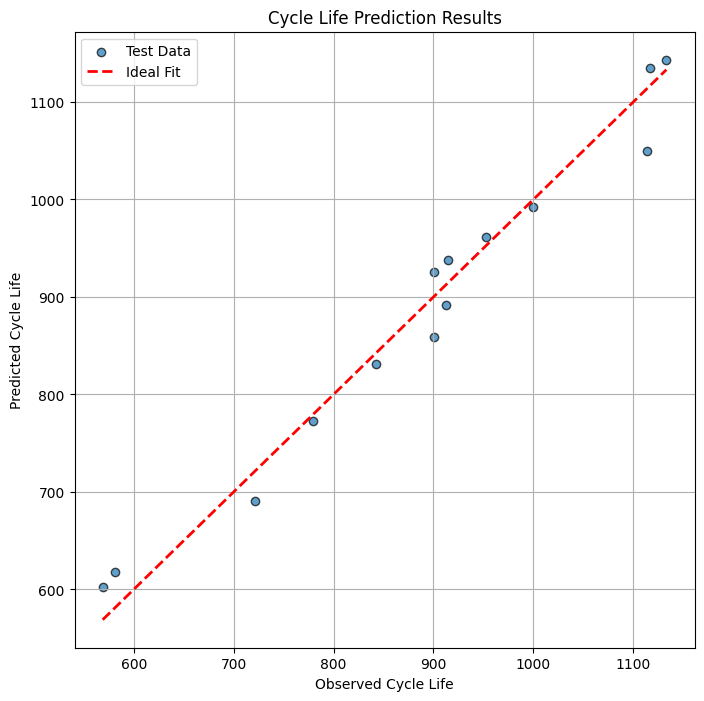

In [ ]:
# Step 4 - Evaluating the Cycle Life Predictor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Get predictions for the test set---
model.eval()
y_pred_scaled_list = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        y_pred_scaled_list.extend(outputs.cpu().numpy())

y_pred_scaled = np.array(y_pred_scaled_list)

# Inverse transform to get actual cycle life values
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_test

# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mape = mean_absolute_percentage_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("--- Cycle Life Prediction Performance (Test Set) ---")
print(f"MAE: {mae:.3f} cycles")
print(f"RMSE: {rmse:.3f} cycles")
print(f"MAPE: {mape:.3f} %")
print(f"R²: {r2:.4f}")

# Calculate the standard deviation of prediction errors for the Bayesian prior
prediction_errors = y_test_actual - y_pred
std_dev_prediction_error = np.std(prediction_errors)
print(f"\nStandard Deviation of Prediction Errors: {std_dev_prediction_error:.2f} (used for Bayesian prior 'v0')")


# Visualize results
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_pred, alpha=0.7, edgecolors='k', label='Test Data')
plt.plot([min(y_test_actual), max(y_test_actual)], [min(y_test_actual), max(y_test_actual)], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Observed Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title("Cycle Life Prediction Results")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 5 Transfer Learning Framework
from scipy.optimize import curve_fit
import emcee
import corner

# Empirical Aging Model (Eq. 1)
def empirical_model(x, theta1, theta2, theta3, theta4):
    return theta1 * np.exp(theta2 * x) + theta3 * np.exp(theta4 * x)

# Transferred Model (Eq. 4)
def transferred_model(params, x_new, base_model_params):
    rho0, lambda0, rho1, lambda1 = params
    theta1, theta2, theta3, theta4 = base_model_params
    
    x_old = rho0 * x_new + lambda0
    C_old = empirical_model(x_old, theta1, theta2, theta3, theta4)
    C_new = rho1 * C_old + lambda1
    return C_new

# Bayesian Framework (Log Probability Functions)
# This part implements the logic from Eq. 7 through 16.
def log_likelihood(params, x_obs, y_obs, base_model_params, log_sigma):
    y_pred = transferred_model(params, x_obs, base_model_params)
    sigma = np.exp(log_sigma)
    return -0.5 * np.sum(((y_obs - y_pred) / sigma) ** 2) - len(y_obs) * np.log(sigma)

def log_prior(params, predicted_cycle_life, v0):
    rho0, lambda0, rho1, lambda1 = params
    
    # Prior for rho0, lambda0 derived from predicted cycle life (Eq. 12)
    # rho0 = (x_old_max - x_old_min) / (x_new_max - x_new_min)
    # Here, x_old_min = x_new_min = 1. x_old_max is cycle life of source, x_new_max is predicted.
    # We model the distribution of the predicted cycle life.
    # This is a simplification; a more complex prior could be built.
    # A simple approach is to penalize deviations from the expected cycle life.
    # The paper suggests p(Cycle_pred) ~ N(mu0, v0). We'll model this for x_new_max.
    # For this implementation, we set a normal prior on the predicted cycle life itself.
    # The actual sampler will solve for parameters that result in this cycle life.
    
    # Priors for rho1, lambda1 (Eq. 13) are N([1, 0], v1)
    mu1 = np.array([1.0, 0.0])
    v1 = 0.1 # Small variance as was suggested in paper
    prior_rho1_lambda1 = -0.5 * np.sum(((np.array([rho1, lambda1]) - mu1) / v1) ** 2)

    # For rho0, lambda0, we use an uninformative prior for simplicity in this implementation,
    # as the likelihood and cycle life constraint will dominate.
    
    return prior_rho1_lambda1 # We will enforce the cycle life prediction in the full probability

def log_probability(params_with_sigma, x_obs, y_obs, base_model_params, predicted_cycle_life, v0):
    params = params_with_sigma[:-1] # rho0, lambda0, rho1, lambda1
    log_sigma = params_with_sigma[-1]
    
    lp = log_prior(params, predicted_cycle_life, v0)
    if not np.isfinite(lp):
        return -np.inf
    
    # Calculate cycle life from current params
    # the source battery's cycle life for this
    source_cycle_life = base_model_params[-1] # append this to the params tuple
    rho0, lambda0, _, _ = params
    # x_old_max = rho0 * x_new_max + lambda0 -> x_new_max = (x_old_max - lambda0) / rho0
    if rho0 == 0: return -np.inf # Avoidinf division by zero
    current_predicted_cycle_life = (source_cycle_life - lambda0) / rho0
    
    # Add the cycle life prior based on the Res-CNN prediction
    cycle_life_prior = -0.5 * ((current_predicted_cycle_life - predicted_cycle_life) / v0) ** 2

    ll = log_likelihood(params, x_obs, y_obs, base_model_params[:-1], log_sigma)
    
    return lp + ll + cycle_life_prior


print("Transfer learning framework and Bayesian functions defined.")

Transfer learning framework and Bayesian functions defined.


In [13]:
# pip install emcee
# pip install corner

In [ ]:
#initial_capacity

1.0472816

Attempting to fit base model with a global optimizer (Basin Hopping)...
Global optimization finished.


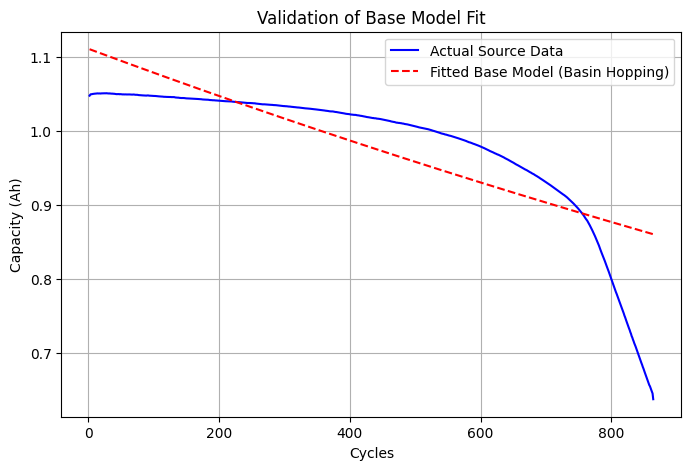


Cycle life prediction for '2019-01-24_batch9_CH6_structure':
Predicted: 992 cycles, True: 1000 cycles

Running MCMC sampler with globally optimized base model...


100%|██████████| 5000/5000 [00:09<00:00, 539.28it/s]



Estimated Transfer Parameters (Posterior Median):
rho0: 0.7016, lambda0: 0.5968 (derived), rho1: 0.5197, lambda1: 0.4987


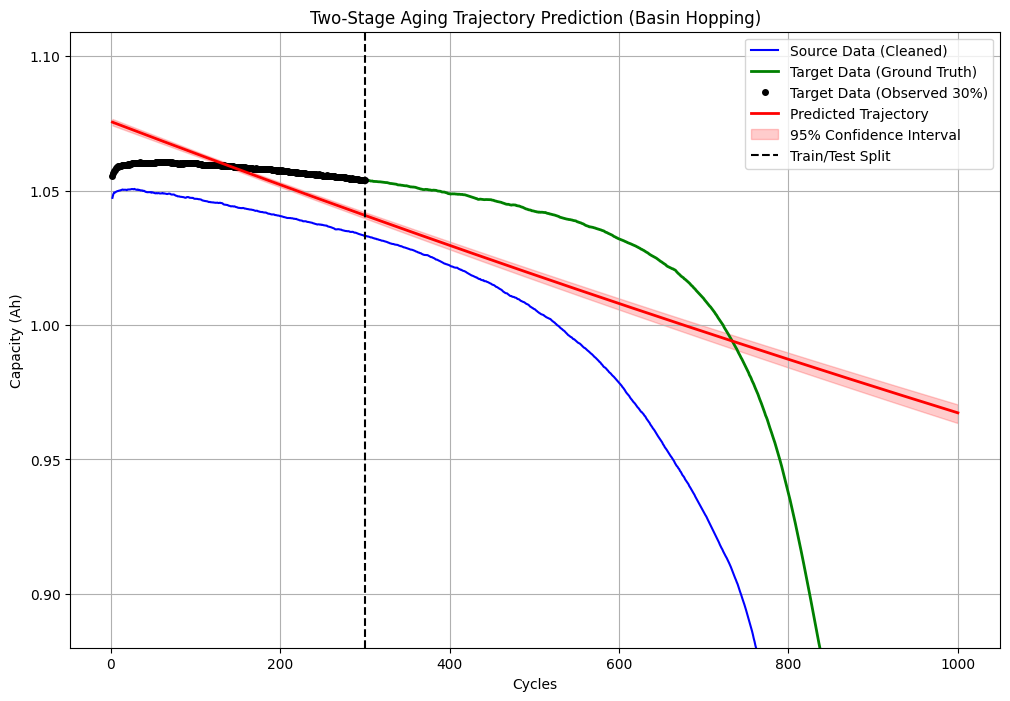


--- Final Trajectory Prediction Performance ---
R²: 0.0459
MAE: 0.0868 Ah
RMSE: 0.1573 Ah


In [ ]:
# Step 6:Using a Global Optimizer (Basin Hopping) for the Base Model -(we can use other optimizers as well)
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, basinhopping
import emcee
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#  Data Preparation with Anomaly Removal 
#  the same source/target for a direct comparison
source_battery_index = 1
target_battery_index = 5

source_battery = batteries_data[source_battery_index]
source_capacity_raw = np.concatenate([source_battery['early_cycles'], source_battery['remaining_cycles']])
source_cycles_raw = np.arange(1, len(source_capacity_raw) + 1)
source_capacity = source_capacity_raw[1:]; source_cycles = source_cycles_raw[1:]

target_battery = batteries_test[target_battery_index]
target_capacity_full_raw = np.concatenate([target_battery['early_cycles'], target_battery['remaining_cycles']])
target_cycles_full_raw = np.arange(1, len(target_capacity_full_raw) + 1)
target_capacity_full = target_capacity_full_raw[1:]; target_cycles_full = target_cycles_full_raw[1:]
observed_cycles = np.arange(2, target_battery['early_cycle_count'] + 1); observed_capacity = target_battery['early_cycles'][1:]

#  1 Train Base Model with Basin Hopping 
print("Attempting to fit base model with a global optimizer (Basin Hopping)...")

# Define an objective function for the optimizer ---
# this calculates the sum of squared errors, which the optimizer will try to minimize.
def objective_function(theta, x_data, y_data):
    return np.sum((y_data - empirical_model(x_data, *theta))**2)

# Set up initial guesses and bounds, similar to before
initial_capacity = source_capacity[0]
initial_guesses = [initial_capacity, -1e-5, 0.1, -1e-3]
bounds = ([0, -np.inf, 0, -np.inf], [np.inf, 0, np.inf, 0])

# Arguments to pass to the local minimizer within basinhopping
minimizer_kwargs = {
    "method": "L-BFGS-B", # A good local optimizer that can handle bounds
    "args": (source_cycles, source_capacity),
    "bounds": list(zip(bounds[0], bounds[1]))
}

#  Call the basinhopping global optimizer 
# niter is the number of "hops" it will perform to search for the best solution.
# This is more computationally intensive but far more robust.
optim_result = basinhopping(
    objective_function,
    x0=initial_guesses,
    minimizer_kwargs=minimizer_kwargs,
    niter=200 # More iterations give a better chance of finding the global minimum
)

base_model_params_theta = optim_result.x
print("Global optimization finished.")

#  Validate the new base model fit 
plt.figure(figsize=(8, 5))
plt.plot(source_cycles, source_capacity, 'b-', label='Actual Source Data')
plt.plot(source_cycles, empirical_model(source_cycles, *base_model_params_theta), 'r--', label='Fitted Base Model (Basin Hopping)')
plt.title("Validation of Base Model Fit")
plt.xlabel("Cycles"); plt.ylabel("Capacity (Ah)")
plt.legend(); plt.grid(True); plt.show()


# use base model parameters found by basinhopping.

# 2 Predict Cycle Life
target_vf_sequence = X_test[target_battery_index:target_battery_index+1]
predicted_cycle_life = y_scaler.inverse_transform(model(torch.FloatTensor(target_vf_sequence).to(device)).cpu().detach().numpy())[0][0]
print(f"\nCycle life prediction for '{target_battery['name']}':")
print(f"Predicted: {predicted_cycle_life:.0f} cycles, True: {target_battery['cycle_life']:.0f} cycles")

# 3 Define Final Log Probability Function
def log_probability_final(params_with_sigma, x_obs, y_obs, base_model_params, predicted_cycle_life, v0):
    rho0, rho1, lambda1, log_sigma = params_with_sigma
    x_old_min = base_model_params[-2]; x_new_min = x_obs[0]
    lambda0 = x_old_min - rho0 * x_new_min
    if not (0.1 < rho0 < 5 and 0.5 < rho1 < 1.5 and -0.5 < lambda1 < 0.5): return -np.inf
    transfer_params = [rho0, lambda0, rho1, lambda1]
    y_pred = transferred_model(transfer_params, x_obs, base_model_params[:-2])
    sigma = np.exp(log_sigma)
    log_likelihood_val = -0.5 * np.sum(((y_obs - y_pred) / sigma) ** 2) - len(y_obs) * np.log(sigma)
    if not np.isfinite(log_likelihood_val): return -np.inf
    mu1 = np.array([1.0, 0.0]); v1 = 0.1
    log_prior_rho1_lambda1 = -0.5 * np.sum(((np.array([rho1, lambda1]) - mu1) / v1) ** 2)
    source_cycle_life = base_model_params[-1]
    current_predicted_cycle_life = (source_cycle_life - lambda0) / rho0
    log_prior_cycle_life = -0.5 * ((current_predicted_cycle_life - predicted_cycle_life) / v0) ** 2
    return log_likelihood_val + log_prior_rho1_lambda1 + log_prior_cycle_life

# 4 Run MCMC Sampler
base_model_params_full = (*base_model_params_theta, source_cycles[0], source_battery['cycle_life'])
n_walkers, n_dim, n_steps, burn_in = 32, 4, 5000, 1000
initial_state = np.array([1.0, 1.0, 0.0, np.log(0.01)])
p0 = initial_state + 1e-3 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability_final, args=(
    observed_cycles, observed_capacity, base_model_params_full, predicted_cycle_life, std_dev_prediction_error
))
print("\nRunning MCMC sampler with globally optimized base model...")
sampler.run_mcmc(p0, n_steps, progress=True)
flat_samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)

# 5 Extract Results
map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
map_lambda0 = source_cycles[0] - map_rho0 * observed_cycles[0]
map_params = [map_rho0, map_lambda0, map_rho1, map_lambda1]
print("\nEstimated Transfer Parameters (Posterior Median):")
print(f"rho0: {map_params[0]:.4f}, lambda0: {map_params[1]:.4f} (derived), rho1: {map_params[2]:.4f}, lambda1: {map_params[3]:.4f}")

# Generate predictions and CI
predictions = []
for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
    rho0, rho1, lambda1 = p[:-1]
    lambda0 = source_cycles[0] - rho0 * observed_cycles[0]
    predictions.append(transferred_model([rho0, lambda0, rho1, lambda1], target_cycles_full, base_model_params_theta))
predictions = np.array(predictions)
mean_prediction = np.mean(predictions, axis=0)
lower_ci, upper_ci = np.percentile(predictions, [2.5, 97.5], axis=0)

# 6 Visualize and Evaluate
plt.figure(figsize=(12, 8))
plt.plot(source_cycles, source_capacity, 'b-', label='Source Data (Cleaned)')
plt.plot(target_cycles_full, target_capacity_full, 'g-', lw=2, label='Target Data (Ground Truth)')
plt.plot(observed_cycles, observed_capacity, 'ko', markersize=4, label='Target Data (Observed 30%)')
plt.plot(target_cycles_full, mean_prediction, 'r-', lw=2, label='Predicted Trajectory')
plt.fill_between(target_cycles_full, lower_ci, upper_ci, color='red', alpha=0.2, label='95% Confidence Interval')
plt.axvline(x=target_battery['early_cycle_count'], color='k', linestyle='--', label='Train/Test Split')
plt.xlabel("Cycles"); plt.ylabel("Capacity (Ah)"); plt.title(f"Two-Stage Aging Trajectory Prediction (Basin Hopping)")
plt.legend(); plt.grid(True); plt.ylim(bottom=0.88); plt.show()

# Calculate Final Metrics
test_start_index = target_battery['early_cycle_count'] -1
y_true_test = target_capacity_full[test_start_index:]
y_pred_test = mean_prediction[test_start_index:]
trajectory_r2 = r2_score(y_true_test, y_pred_test)
trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)
trajectory_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
print("\n--- Final Trajectory Prediction Performance ---")
print(f"R²: {trajectory_r2:.4f}"); print(f"MAE: {trajectory_mae:.4f} Ah"); print(f"RMSE: {trajectory_rmse:.4f} Ah")

In [ ]:
import pandas as pd

# DataFrame for the Fitted Base Model

#  the C(x) values for the red dotted line
fitted_capacity_values = empirical_model(source_cycles, *base_model_params_theta)

df_fitted_base_model = pd.DataFrame({
    'Cycle (x)': source_cycles,
    'Fitted_Capacity_C(x)': fitted_capacity_values
})


In [84]:
base_model_params_theta

array([ 3.11393713e-02, -1.15645443e+06,  1.11070337e+00, -2.95948576e-04])

In [86]:

df_fitted_base_model.head(50)



,Cycle (x),Fitted_Capacity_C(x)
0,2,1.110046
1,3,1.109718
2,4,1.109389
3,5,1.109061
4,6,1.108733
5,7,1.108405
6,8,1.108077
7,9,1.107749
8,10,1.107421
9,11,1.107093


Fitting 4th-order polynomial base model for source battery 1...
Polynomial fit finished.


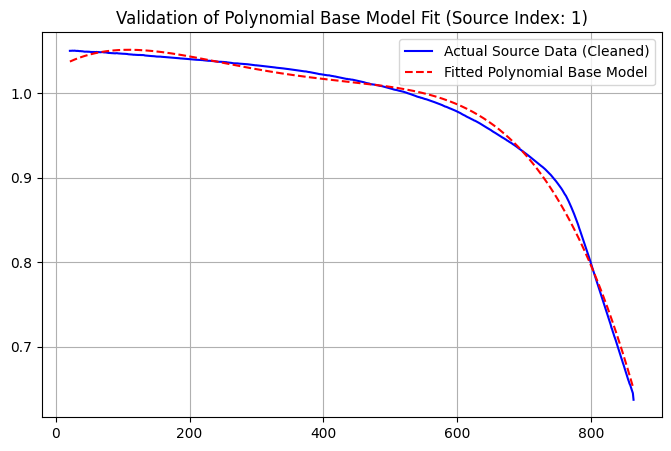


Running MCMC sampler with polynomial base model...


100%|██████████| 5000/5000 [00:09<00:00, 552.27it/s]


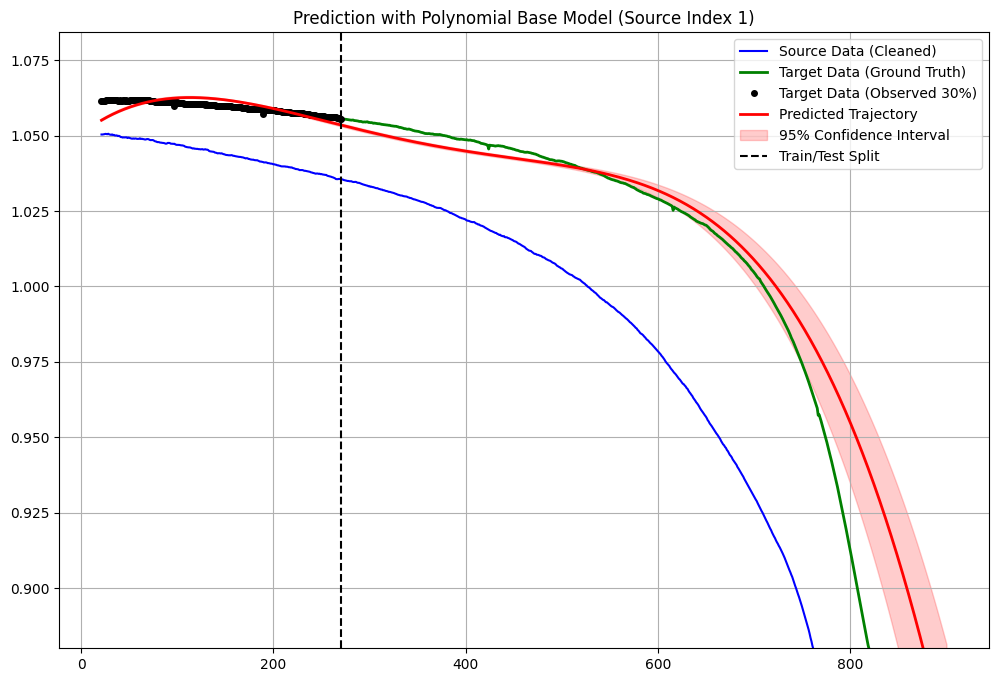


--- Final Trajectory Prediction Performance ---
R²:   0.7957
MAE:  0.0189 Ah
RMSE: 0.0388 Ah
MAPE: 2.2700 %


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import emcee
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Define Helper Function for MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define the polynomial base model
def polynomial_model(x, p):
    """Evaluates a polynomial model. 'p' is a list of coefficients."""
    return np.polyval(p, x)

# Define the transfer model for the polynomial base
def transferred_model_poly(transfer_params, x_new, base_model_poly_params):
    rho0, lambda0, rho1, lambda1 = transfer_params
    x_old = rho0 * x_new + lambda0
    C_old = polynomial_model(x_old, base_model_poly_params)
    C_new = rho1 * C_old + lambda1
    return C_new

# Update the Bayesian probability function to use the polynomial model
def log_probability_poly(params_with_sigma, x_obs, y_obs, base_model_params, predicted_cycle_life, v0):
    rho0, rho1, lambda1, log_sigma = params_with_sigma
    poly_params, x_old_min, source_cycle_life = base_model_params
    x_new_min = x_obs[0]
    lambda0 = x_old_min - rho0 * x_new_min
    
    if not (0.1 < rho0 < 5 and 0.5 < rho1 < 1.5 and -0.5 < lambda1 < 0.5): return -np.inf

    transfer_params = [rho0, lambda0, rho1, lambda1]
    y_pred = transferred_model_poly(transfer_params, x_obs, poly_params)
    sigma = np.exp(log_sigma)
    log_likelihood_val = -0.5 * np.sum(((y_obs - y_pred) / sigma) ** 2) - len(y_obs) * np.log(sigma)
    if not np.isfinite(log_likelihood_val): return -np.inf
        
    mu1 = np.array([1.0, 0.0]); v1 = 0.1
    log_prior_rho1_lambda1 = -0.5 * np.sum(((np.array([rho1, lambda1]) - mu1) / v1) ** 2)
    current_predicted_cycle_life = (source_cycle_life - lambda0) / rho0
    log_prior_cycle_life = -0.5 * ((current_predicted_cycle_life - predicted_cycle_life) / v0) ** 2
    
    return log_likelihood_val + log_prior_rho1_lambda1 + log_prior_cycle_life

# Setup: Choose a source and target 
source_battery_index = 1
target_battery_index = 7
cycles_to_skip = 20

# Data Preparation 
source_battery = batteries_data[source_battery_index]
source_capacity_raw = np.concatenate([source_battery['early_cycles'], source_battery['remaining_cycles']])
source_cycles_raw = np.arange(1, len(source_capacity_raw) + 1)
source_capacity = source_capacity_raw[cycles_to_skip:]; source_cycles = source_cycles_raw[cycles_to_skip:]

target_battery = batteries_test[target_battery_index]
target_capacity_full_raw = np.concatenate([target_battery['early_cycles'], target_battery['remaining_cycles']])
target_cycles_full_raw = np.arange(1, len(target_capacity_full_raw) + 1)
target_capacity_full = target_capacity_full_raw[cycles_to_skip:]; target_cycles_full = target_cycles_full_raw[cycles_to_skip:]
original_split_cycle = target_battery['early_cycle_count']
observed_start_cycle = cycles_to_skip + 1
observed_cycles_full_range = np.arange(observed_start_cycle, original_split_cycle + 1)
start_index_obs = np.where(target_cycles_full_raw == observed_start_cycle)[0][0]
end_index_obs = np.where(target_cycles_full_raw == original_split_cycle)[0][0]
observed_capacity = target_capacity_full_raw[start_index_obs : end_index_obs + 1]

#  1 Train the NEW Polynomial Base Model 
print(f"Fitting 4th-order polynomial base model for source battery {source_battery_index}...")
poly_coeffs = np.polyfit(source_cycles, source_capacity, 4)
print("Polynomial fit finished.")

#  Validate the new base model fit 
plt.figure(figsize=(8, 5))
plt.plot(source_cycles, source_capacity, 'b-', label='Actual Source Data (Cleaned)')
plt.plot(source_cycles, polynomial_model(source_cycles, poly_coeffs), 'r--', label='Fitted Polynomial Base Model')
plt.title(f"Validation of Polynomial Base Model Fit (Source Index: {source_battery_index})")
plt.legend(); plt.grid(True); plt.show()

#  2 Predict Cycle Life
target_vf_sequence = X_test[target_battery_index:target_battery_index+1]
predicted_cycle_life = y_scaler.inverse_transform(model(torch.FloatTensor(target_vf_sequence).to(device)).cpu().detach().numpy())[0][0]

#  3 Run MCMC Sampler with the NEW Polynomial Model
base_model_params_full = (poly_coeffs, source_cycles[0], source_battery['cycle_life'])
n_walkers, n_dim, n_steps, burn_in = 32, 4, 5000, 1000
initial_state = np.array([1.0, 1.0, 0.0, np.log(0.01)])
p0 = initial_state + 1e-3 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability_poly, args=(
    observed_cycles_full_range, observed_capacity, base_model_params_full, predicted_cycle_life, std_dev_prediction_error
))
print("\nRunning MCMC sampler with polynomial base model...")
sampler.run_mcmc(p0, n_steps, progress=True)
flat_samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)

# 4 Extract Results
map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
map_lambda0 = source_cycles[0] - map_rho0 * observed_cycles_full_range[0]

#5 Generate Predictions and Visualize 
predictions = []
for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
    rho0, rho1, lambda1 = p[:-1]
    lambda0 = source_cycles[0] - rho0 * observed_cycles_full_range[0]
    predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], target_cycles_full, poly_coeffs))
mean_prediction = np.mean(np.array(predictions), axis=0)
lower_ci, upper_ci = np.percentile(np.array(predictions), [2.5, 97.5], axis=0)

plt.figure(figsize=(12, 8))
plt.plot(source_cycles, source_capacity, 'b-', label='Source Data (Cleaned)')
plt.plot(target_cycles_full, target_capacity_full, 'g-', lw=2, label='Target Data (Ground Truth)')
plt.plot(observed_cycles_full_range, observed_capacity, 'ko', markersize=4, label='Target Data (Observed 30%)')
plt.plot(target_cycles_full, mean_prediction, 'r-', lw=2, label='Predicted Trajectory')
plt.fill_between(target_cycles_full, lower_ci, upper_ci, color='red', alpha=0.2, label='95% Confidence Interval')
plt.axvline(x=original_split_cycle, color='k', linestyle='--', label='Train/Test Split')
plt.title(f"Prediction with Polynomial Base Model (Source Index {source_battery_index})")
plt.legend(); plt.grid(True); plt.ylim(bottom=0.88); plt.show()


#Final Metrics
test_start_index = np.where(target_cycles_full == original_split_cycle)[0][0]
y_true_test = target_capacity_full[test_start_index:]
y_pred_test = mean_prediction[test_start_index:]


trajectory_r2 = r2_score(y_true_test, y_pred_test)
trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)
trajectory_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
trajectory_mape = mean_absolute_percentage_error(y_true_test, y_pred_test)

print(f"\n--- Final Trajectory Prediction Performance ---")
print(f"R²:   {trajectory_r2:.4f}")
print(f"MAE:  {trajectory_mae:.4f} Ah")
print(f"RMSE: {trajectory_rmse:.4f} Ah")
print(f"MAPE: {trajectory_mape:.4f} %")


--- Running Test: Source Index 1 -> Target Index 11 ---
Cycle life prediction for target: 1135 cycles (True: 1117)


100%|██████████| 5000/5000 [00:09<00:00, 520.84it/s]


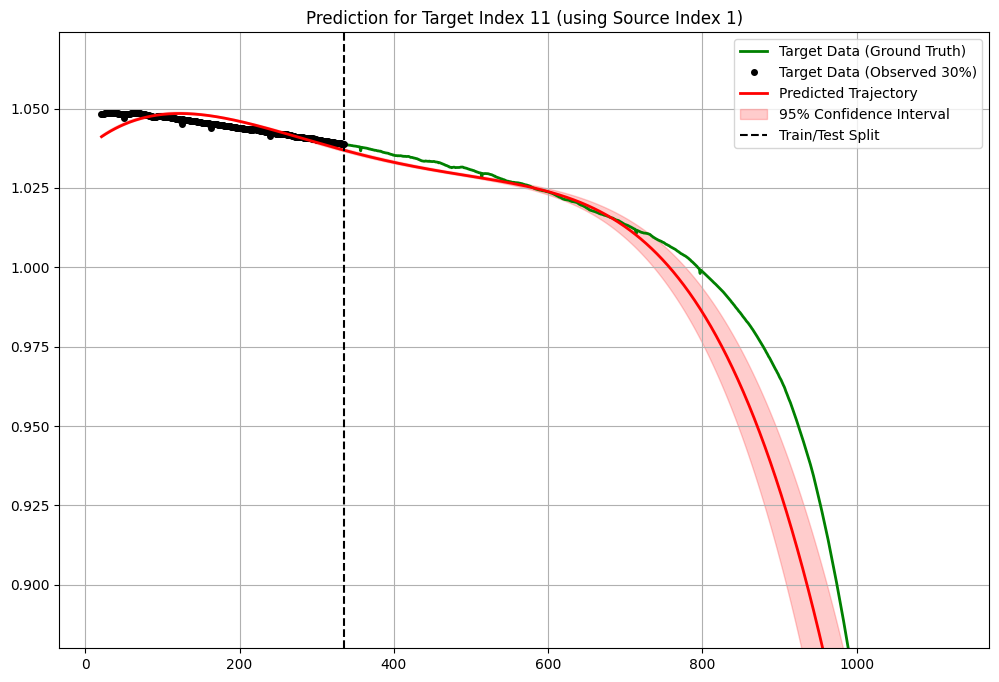


--- Final Trajectory Prediction Performance ---
R²:   0.9587
MAE:  0.0134 Ah
RMSE: 0.0196 Ah
MAPE: 1.5024 %


In [78]:
run_transfer_learning_test(source_index=1, target_index=11)

In [87]:
poly_coeffs

array([-5.08558427e-12,  6.90056873e-09, -3.23641255e-06,  4.86653050e-04,
        1.02879839e+00])

In [ ]:
# This cell defines a single function to run the entire test.
# Make sure all previous cells (data loading, Res-CNN training, etc.) have been run.

#Helper Function for MAPE (included again
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Add a small epsilon to the denominator to avoid division by zero
    epsilon = 1e-9
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

def run_transfer_learning_test(source_index, target_index):
    """
    Performs the complete two-stage aging trajectory prediction for a given
    source and target battery.

    Args:
        source_index (int): The index of the battery to use as the source model.
        target_index (int): The index of the battery in the test set to predict.
    """
    print(f"\n{'='*60}\n--- Running Test: Source Index {source_index} -> Target Index {target_index} ---\n{'='*60}")

    #  1 PREPARE BASE MODEL FROM SOURCE 
    source_battery = batteries_data[source_index]
    source_capacity_raw = np.concatenate([source_battery['early_cycles'], source_battery['remaining_cycles']])
    source_cycles_raw = np.arange(1, len(source_capacity_raw) + 1)
    cycles_to_skip = 20
    source_capacity = source_capacity_raw[cycles_to_skip:]
    source_cycles = source_cycles_raw[cycles_to_skip:]
    
    # Fit the robust polynomial base model
    poly_coeffs = np.polyfit(source_cycles, source_capacity, 4)
    
    #  2 PREPARE NEW TARGET DATA 
    target_battery = batteries_test[target_index]
    target_capacity_full_raw = np.concatenate([target_battery['early_cycles'], target_battery['remaining_cycles']])
    target_cycles_full_raw = np.arange(1, len(target_capacity_full_raw) + 1)
    target_capacity_full = target_capacity_full_raw[cycles_to_skip:]
    target_cycles_full = target_cycles_full_raw[cycles_to_skip:]
    
    original_split_cycle = target_battery['early_cycle_count']
    observed_start_cycle = cycles_to_skip + 1
    
    if original_split_cycle <= cycles_to_skip:
        print("ERROR: Observation window is entirely within the skipped period. Cannot test.")
        return

    observed_cycles_full_range = np.arange(observed_start_cycle, original_split_cycle + 1)
    start_index_obs = np.where(target_cycles_full_raw == observed_start_cycle)[0][0]
    end_index_obs = np.where(target_cycles_full_raw == original_split_cycle)[0][0]
    observed_capacity = target_capacity_full_raw[start_index_obs : end_index_obs + 1]

    #  3 PREDICT CYCLE LIFE 
    target_vf_sequence = X_test[target_index:target_index+1]
    predicted_cycle_life = y_scaler.inverse_transform(model(torch.FloatTensor(target_vf_sequence).to(device)).cpu().detach().numpy())[0][0]
    print(f"Cycle life prediction for target: {predicted_cycle_life:.0f} cycles (True: {target_battery['cycle_life']:.0f})")

    #  4 RUN MCMC SAMPLER 
    base_model_params_full = (poly_coeffs, source_cycles[0], source_battery['cycle_life'])
    n_walkers, n_dim, n_steps, burn_in = 32, 4, 5000, 1000
    initial_state = np.array([1.0, 1.0, 0.0, np.log(0.01)])
    p0 = initial_state + 1e-3 * np.random.randn(n_walkers, n_dim)

    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability_poly, args=(
        observed_cycles_full_range, observed_capacity, base_model_params_full, predicted_cycle_life, std_dev_prediction_error
    ))
    sampler.run_mcmc(p0, n_steps, progress=True)
    flat_samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)

    #  5 VISUALIZE AND EVALUATE 
    map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
    map_lambda0 = source_cycles[0] - map_rho0 * observed_cycles_full_range[0]
    
    predictions = []
    for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
        rho0, rho1, lambda1 = p[:-1]
        lambda0 = source_cycles[0] - rho0 * observed_cycles_full_range[0]
        predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], target_cycles_full, poly_coeffs))
    mean_prediction = np.mean(np.array(predictions), axis=0)
    lower_ci, upper_ci = np.percentile(np.array(predictions), [2.5, 97.5], axis=0)

    plt.figure(figsize=(12, 8))
    plt.plot(target_cycles_full, target_capacity_full, 'g-', lw=2, label='Target Data (Ground Truth)')
    plt.plot(observed_cycles_full_range, observed_capacity, 'ko', markersize=4, label='Target Data (Observed 30%)')
    plt.plot(target_cycles_full, mean_prediction, 'r-', lw=2, label='Predicted Trajectory')
    plt.fill_between(target_cycles_full, lower_ci, upper_ci, color='red', alpha=0.2, label='95% Confidence Interval')
    plt.axvline(x=original_split_cycle, color='k', linestyle='--', label='Train/Test Split')
    plt.title(f"Prediction for Target Index {target_index} (using Source Index {source_index})")
    plt.legend(); plt.grid(True); plt.ylim(bottom=0.88); plt.show()

    test_start_index = np.where(target_cycles_full == original_split_cycle)[0][0]
    y_true_test = target_capacity_full[test_start_index:]
    y_pred_test = mean_prediction[test_start_index:]
    
    # Calculate all four metrics 
    trajectory_r2 = r2_score(y_true_test, y_pred_test)
    trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)
    trajectory_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    trajectory_mape = mean_absolute_percentage_error(y_true_test, y_pred_test)
    
    print(f"\n Final Trajectory Prediction Performance ")
    print(f"R²:   {trajectory_r2:.4f}")
    print(f"MAE:  {trajectory_mae:.4f} Ah")
    print(f"RMSE: {trajectory_rmse:.4f} Ah")
    print(f"MAPE: {trajectory_mape:.4f} %")


